In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.features.overall_analysis import EEGSummarizedAnalyzer
from src.definitions.fields import (
    ExperimentNames,
    CoordinateSystems,
    ConditionVariants,
    MusicTypeVariants,
    ExclusionCategories,
    SingleDataMetadata
)
from src.definitions.constants import ProjectPaths

from xvfbwrapper import Xvfb
vdisplay = Xvfb()
vdisplay.start()

%matplotlib inline
# %matplotlib qt


## Setup

Create two `EEGSummarizedAnalyzer` instances — one for **Classical** and one for **Psytrance** music.
Each filters participants, loads matching recordings, resamples to 250 Hz,
stacks them into an `(n_subjects, n_channels, n_times)` array, and applies z-score normalisation.

In [2]:
# process_and_save_data = True
process_and_save_data = False

def make_analyzer(music_type):
    """Create, load and normalise an analyzer for one music type."""
    a = EEGSummarizedAnalyzer(
        experiment_name=ExperimentNames.PSILO_MUSIC,
        coordinate_system=CoordinateSystems.HYDROGEL_257_NO_FIDUCIALS,
        music_types=[music_type],
        conditions=[ConditionVariants.PLACEBO],
        exclusion_categories=[ExclusionCategories.BAD_MUSIC],
    )
    if process_and_save_data:
        a.load_and_prepare_data(resample_freq=250.0, n_jobs=-1)
        print(f"[{music_type.value}] data shape: {a.data.shape}")
        a.save_data()
    else:
        a.load_data(
            info_filename=a.filtered_df[SingleDataMetadata.FILENAME].iloc[0],
        )
        print(f"[{music_type.value}] Loaded data shape: {a.data.shape}")
    a.normalize()
    return a

analyzer_classical = make_analyzer(MusicTypeVariants.CLASSICAL)
analyzer_psytrance = make_analyzer(MusicTypeVariants.PSYTRANCE)

# Ordered dict for easy iteration in all subsequent cells
analyzers = {
    "Classical": analyzer_classical,
    "Psytrance": analyzer_psytrance,
}

Opening raw data file /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI035_EEGB_MUSIC_CLASSIC_EC_20180209_124821.fif...
    Range : 19254 ... 384821 =     19.254 ...   384.821 secs
Ready.


/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/../src/data/dataset_handler.py:173: RuntimeWarning: This filename (/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI035_EEGB_MUSIC_CLASSIC_EC_20180209_124821.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(


[CLASSIC] Loaded data shape: (16, 195, 91392)
Opening raw data file /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI040_EEGB_MUSIC_PSYTRANCE_EC_20181011_124255.fif...


/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/../src/data/dataset_handler.py:173: RuntimeWarning: This filename (/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI040_EEGB_MUSIC_PSYTRANCE_EC_20181011_124255.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(


    Range : 23383 ... 508124 =     23.383 ...   508.124 secs
Ready.
[PSYTRANCE] Loaded data shape: (20, 195, 121186)


## Analysis — Inter-Subject Correlation (ISC)

`compute_loo_isc` computes the leave-one-out ISC for every channel:
for each subject *s*, the Pearson correlation between subject *s* and the mean of all
other subjects is calculated. Returns per-subject ISC `(n_subjects, n_channels)` and
the subject-mean `(n_channels,)`.

Both music types are computed and shown side-by-side.

In [3]:
# Compute LOO-ISC for both music types
loo_iscs = {}
mean_loo_iscs = {}
for label, a in analyzers.items():
    loo_isc, mean_loo_isc = a.compute_loo_isc()
    loo_iscs[label] = loo_isc
    mean_loo_iscs[label] = mean_loo_isc
    print(f"[{label}]  loo_isc: {loo_isc.shape}   mean_loo_isc: {mean_loo_isc.shape}")

[Classical]  loo_isc: (16, 195)   mean_loo_isc: (195,)
[Psytrance]  loo_isc: (20, 195)   mean_loo_isc: (195,)


RuntimeError: You must provide 2 axes (one for each time plus one for the colorbar), got 1.

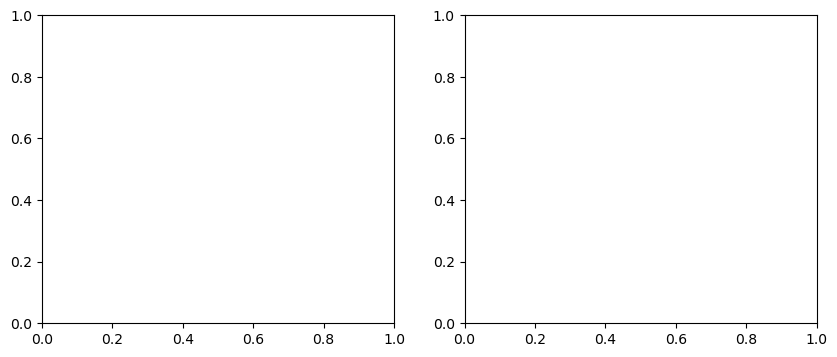

In [22]:
import mne

# Topomap of mean LOO-ISC — one column per music type
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (label, a) in zip(axes, analyzers.items()):
    eeg_picks = mne.pick_types(a.info, eeg=True)
    eeg_info = mne.pick_info(a.info, eeg_picks)
    evoked = mne.EvokedArray(
        mean_loo_iscs[label][eeg_picks].reshape(-1, 1), eeg_info, tmin=0.0
    )
    evoked.plot_topomap(
        times=[0], scalings=1, units="ISC (r)", cmap="RdBu_r",
        axes=ax, show=False, colorbar=True,
    )
    ax.set_title(f"{label} — mean LOO-ISC")
plt.suptitle("Topomap of mean LOO-ISC across channels", y=1.02)
plt.tight_layout()
plt.show()

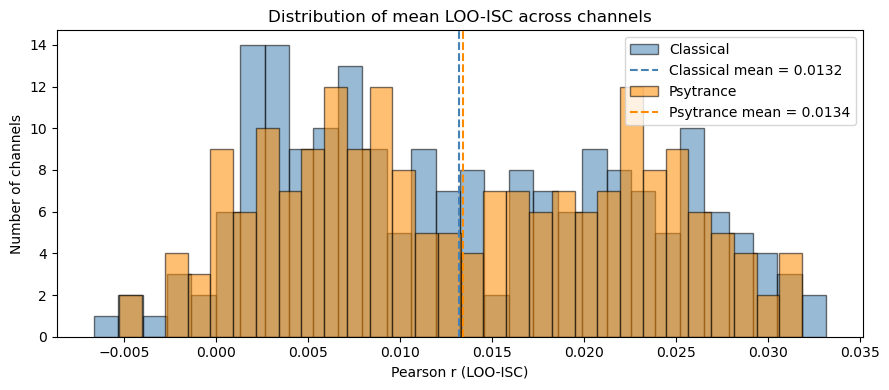

In [5]:
# Distribution of mean LOO-ISC — both music types overlaid
fig, ax = plt.subplots(figsize=(9, 4))
colors = {"Classical": "steelblue", "Psytrance": "darkorange"}
for label, mean_isc in mean_loo_iscs.items():
    ax.hist(mean_isc, bins=30, alpha=0.55, edgecolor="black",
            color=colors[label], label=label)
    ax.axvline(mean_isc.mean(), color=colors[label], ls="--", lw=1.5,
               label=f"{label} mean = {mean_isc.mean():.4f}")
ax.set_xlabel("Pearson r (LOO-ISC)")
ax.set_ylabel("Number of channels")
ax.set_title("Distribution of mean LOO-ISC across channels")
ax.legend()
plt.tight_layout()
plt.show()

## Data Overview

High-level summary of the loaded data array: number of subjects, channels, time-points, recording duration and sampling frequency.

In [6]:
# Data overview for both music types
for label, a in analyzers.items():
    n_subjects, n_channels, n_times = a.data.shape
    sfreq = a.resample_freq if a.resample_freq is not None else a.info["sfreq"]
    duration_sec = n_times / sfreq
    print(f"--- {label} ---")
    print(f"  Subjects   : {n_subjects}")
    print(f"  Channels   : {n_channels}")
    print(f"  Time points: {n_times}")
    print(f"  Sfreq      : {sfreq} Hz")
    print(f"  Duration   : {duration_sec:.1f} s  ({duration_sec / 60:.1f} min)")
    print(f"  Data dtype : {a.data.dtype}")
    print(f"  Data range : [{a.data.min():.3f}, {a.data.max():.3f}]")
    print()

--- Classical ---
  Subjects   : 16
  Channels   : 195
  Time points: 91392
  Sfreq      : 250.0 Hz
  Duration   : 365.6 s  (6.1 min)
  Data dtype : float64
  Data range : [-62.572, 48.960]

--- Psytrance ---
  Subjects   : 20
  Channels   : 195
  Time points: 121186
  Sfreq      : 250.0 Hz
  Duration   : 484.7 s  (8.1 min)
  Data dtype : float64
  Data range : [-67.540, 48.453]



## Sliding-Window ISC (Time-Resolved Synchrony)

Instead of collapsing the entire recording into one ISC value, a sliding window
(default 5 s, step 2.5 s) is moved across time.  Inside each window the LOO-ISC
is computed and averaged across subjects, producing a time course of synchrony
per channel.  This reveals **when** during the music the listeners' brains are
most synchronised.

In [7]:
# Compute sliding-window ISC (5 s windows, 2.5 s step) for both music types
sw_results = {}   # label -> {"isc": (n_windows, n_channels), "times": (n_windows,)}
for label, a in analyzers.items():
    sw_isc, sw_times = a.compute_sliding_window_isc(
        window_sec=5, step_sec=2.5, sfreq=a.resample_freq
    )
    sw_results[label] = {"isc": sw_isc, "times": sw_times}
    print(f"[{label}]  sw_isc: {sw_isc.shape}   sw_times: {sw_times.shape}")

[Classical]  sw_isc: (145, 195)   sw_times: (145,)
[Psytrance]  sw_isc: (192, 195)   sw_times: (192,)


[Classical] Significant windows (r > 0.035): 13/145 (9.0 %)
[Psytrance] Significant windows (r > 0.035): 19/192 (9.9 %)


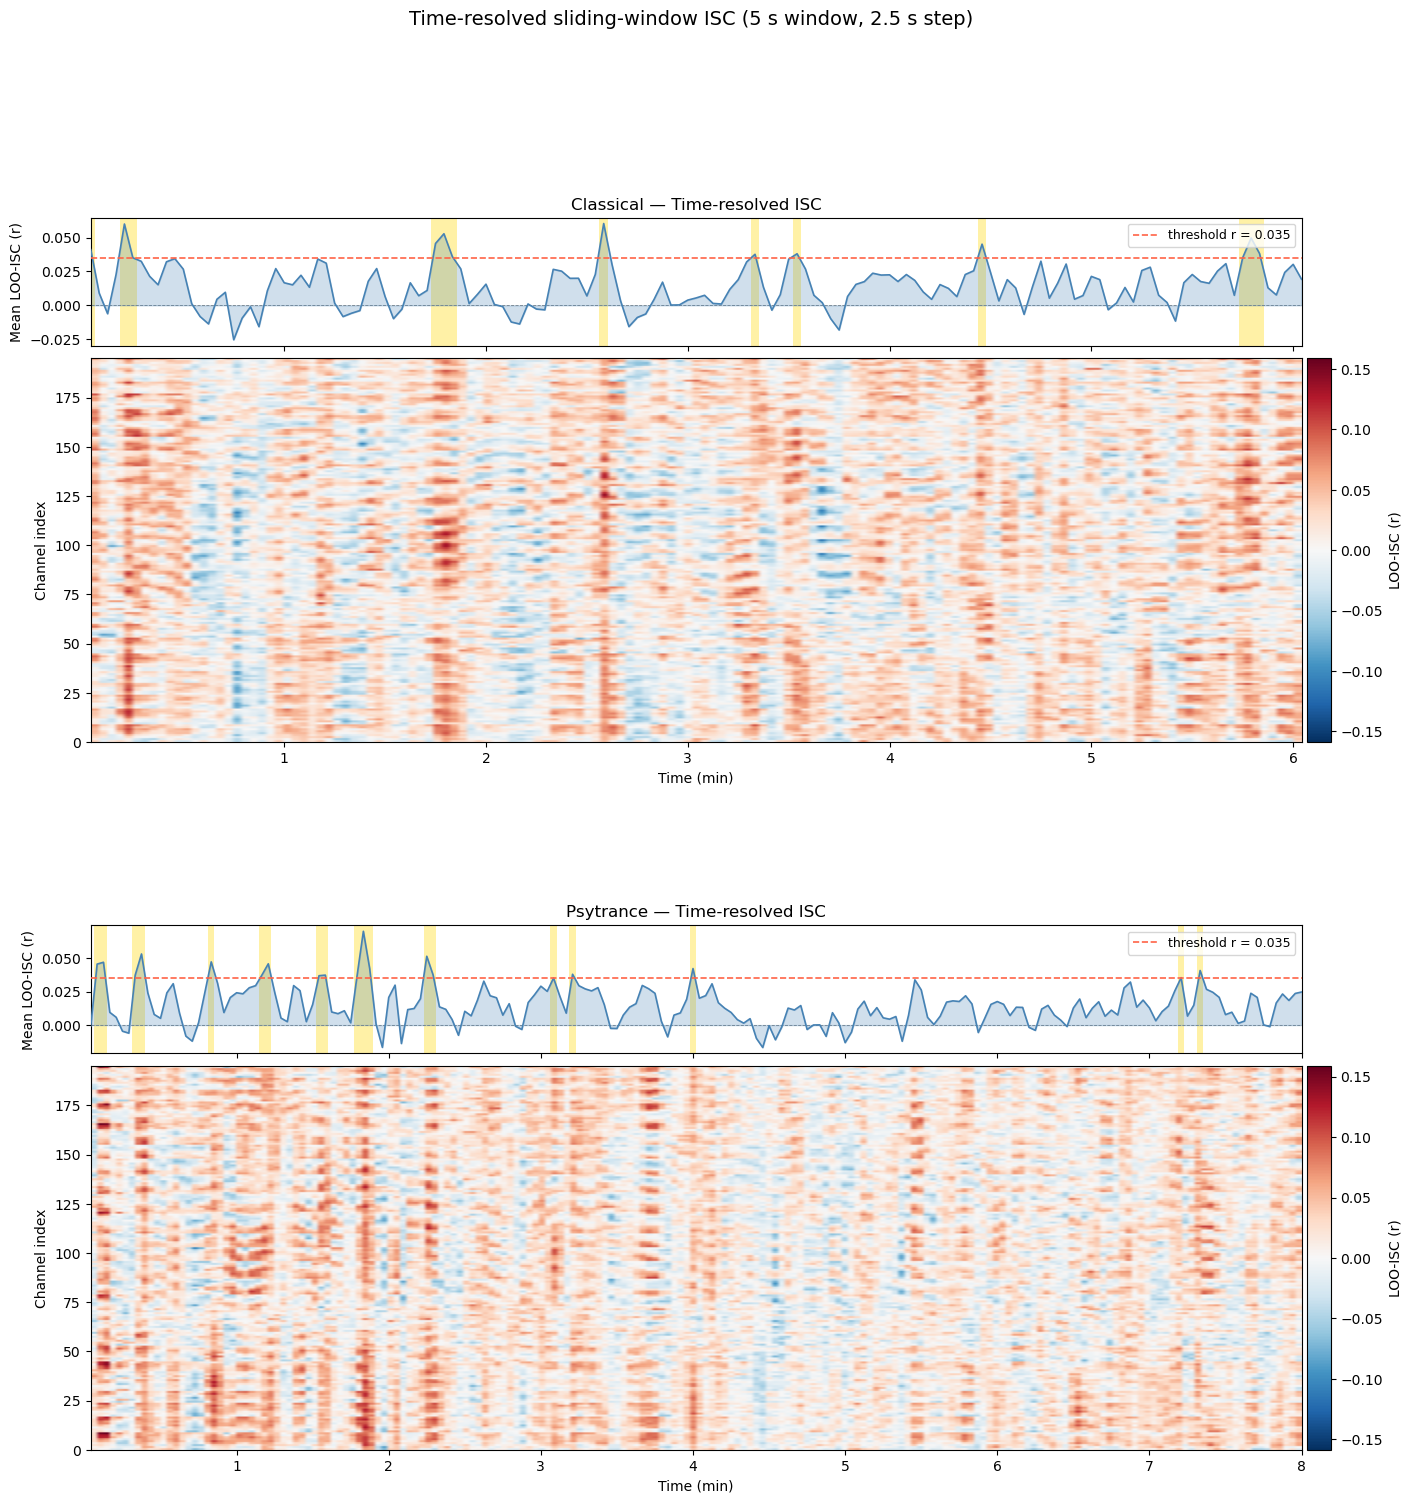

In [21]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

ISC_THRESHOLD = 0.035   # significance threshold (r)
COLORS = {"Classical": "steelblue", "Psytrance": "steelblue"}

# Outer grid: 2 rows (one per music type) with generous gap between them
fig = plt.figure(figsize=(16, 16))
outer_gs = GridSpec(2, 1, figure=fig, hspace=0.35)

# Inner grid per music type: tight gap between mean-ISC and heatmap rows
inner_grids = []
for outer_row in range(2):
    gs = GridSpecFromSubplotSpec(
        2, 1, subplot_spec=outer_gs[outer_row],
        height_ratios=[1, 3], hspace=0.05,
    )
    inner_grids.append(gs)

axes_top = [fig.add_subplot(inner_grids[0][0]), fig.add_subplot(inner_grids[1][0])]
axes_bot = [fig.add_subplot(inner_grids[0][1]), fig.add_subplot(inner_grids[1][1])]

row_pairs = list(zip(analyzers.keys(), axes_top, axes_bot))

# Shared vmax across both music types for comparable colorscales
global_vmax = max(np.nanmax(np.abs(r["isc"])) for r in sw_results.values())

for label, ax_top, ax_bot in row_pairs:
    sw_isc = sw_results[label]["isc"]
    sw_times = sw_results[label]["times"]
    time_min = sw_times / 60
    t_start, t_end = time_min[0], time_min[-1]
    half_step = (time_min[1] - time_min[0]) / 2
    mean_sw_isc = sw_isc.mean(axis=1)
    sig_mask = mean_sw_isc > ISC_THRESHOLD
    color = COLORS[label]

    # Shade significant windows on both rows
    for ax in (ax_top, ax_bot):
        for i, is_sig in enumerate(sig_mask):
            if is_sig:
                ax.axvspan(
                    time_min[i] - half_step, time_min[i] + half_step,
                    color="gold", alpha=0.35, linewidth=0,
                )

    # Top: mean ISC time course
    ax_top.plot(time_min, mean_sw_isc, color=color, lw=1.2, zorder=3)
    ax_top.fill_between(time_min, mean_sw_isc, alpha=0.25, color=color, zorder=2)
    ax_top.axhline(0, color="grey", ls="--", lw=0.6, zorder=1)
    ax_top.axhline(ISC_THRESHOLD, color="tomato", ls="--", lw=1.2, zorder=3,
                   label=f"threshold r = {ISC_THRESHOLD}")
    ax_top.set_xlim(t_start, t_end)
    ax_top.set_ylabel("Mean LOO-ISC (r)")
    ax_top.set_title(f"{label} — Time-resolved ISC")
    ax_top.tick_params(labelbottom=False)
    ax_top.legend(loc="upper right", fontsize=9)
    div_top = make_axes_locatable(ax_top)
    div_top.append_axes("right", size="2%", pad=0.05).set_visible(False)

    # Bottom: heatmap
    im = ax_bot.imshow(
        sw_isc.T, aspect="auto", origin="lower", cmap="RdBu_r",
        extent=[t_start, t_end, 0, sw_isc.shape[1]],
        vmin=-global_vmax, vmax=global_vmax, zorder=1,
    )
    ax_bot.set_xlim(t_start, t_end)
    ax_bot.set_xlabel("Time (min)")
    ax_bot.set_ylabel("Channel index")
    div_bot = make_axes_locatable(ax_bot)
    cax = div_bot.append_axes("right", size="2%", pad=0.05)
    plt.colorbar(im, cax=cax, label="LOO-ISC (r)")

    n_sig = sig_mask.sum()
    print(f"[{label}] Significant windows (r > {ISC_THRESHOLD}): "
          f"{n_sig}/{len(sig_mask)} ({100*n_sig/len(sig_mask):.1f} %)")

fig.suptitle("Time-resolved sliding-window ISC (5 s window, 2.5 s step)",
             y=1.01, fontsize=14)
plt.show()

In [13]:
# Print contiguous significant intervals (r > ISC_THRESHOLD) for both music types
from itertools import groupby
from operator import itemgetter

header = (f"{'#':>3}  {'Start (min)':>11}  {'End (min)':>9}  "
          f"{'Duration (s)':>12}  {'Mean r':>8}  {'Peak r':>8}")
sep = "-" * 62

for label in analyzers:
    sw_isc   = sw_results[label]["isc"]
    sw_times = sw_results[label]["times"]
    time_min = sw_times / 60
    half_step = (time_min[1] - time_min[0]) / 2
    mean_sw_isc = sw_isc.mean(axis=1)
    sig_mask = mean_sw_isc > ISC_THRESHOLD
    n_sig = sig_mask.sum()

    sig_indices = np.where(sig_mask)[0].tolist()
    intervals = []
    for _, group in groupby(enumerate(sig_indices), lambda x: x[1] - x[0]):
        run = list(map(itemgetter(1), group))
        t_begin  = time_min[run[0]] - half_step
        t_finish = time_min[run[-1]] + half_step
        peak_idx = run[np.argmax(mean_sw_isc[run])]
        intervals.append((t_begin, t_finish,
                          mean_sw_isc[run].mean(),
                          mean_sw_isc[peak_idx]))

    print(f"=== {label} ===")
    print(f"Threshold: r > {ISC_THRESHOLD}   |   "
          f"Significant windows: {n_sig}/{len(sig_mask)} ({100*n_sig/len(sig_mask):.1f} %)\n")
    print(header)
    print(sep)
    for k, (tb, tf, mean_r, peak_r) in enumerate(intervals, 1):
        dur_s = (tf - tb) * 60
        print(f"{k:>3}  {tb:>11.3f}  {tf:>9.3f}  {dur_s:>12.1f}  "
              f"{mean_r:>8.4f}  {peak_r:>8.4f}")
    print()

=== Classical ===
Threshold: r > 0.035   |   Significant windows: 13/145 (9.0 %)

  #  Start (min)  End (min)  Duration (s)    Mean r    Peak r
--------------------------------------------------------------
  1        0.021      0.062           2.5    0.0411    0.0411
  2        0.188      0.271           5.0    0.0475    0.0600
  3        1.729      1.854           7.5    0.0448    0.0528
  4        2.562      2.604           2.5    0.0603    0.0603
  5        3.312      3.354           2.5    0.0377    0.0377
  6        3.521      3.562           2.5    0.0380    0.0380
  7        4.438      4.479           2.5    0.0451    0.0451
  8        5.729      5.854           7.5    0.0410    0.0496

=== Psytrance ===
Threshold: r > 0.035   |   Significant windows: 19/192 (9.9 %)

  #  Start (min)  End (min)  Duration (s)    Mean r    Peak r
--------------------------------------------------------------
  1        0.062      0.146           5.0    0.0462    0.0469
  2        0.312      0.396